# 05 · Analyse des erreurs du modèle en production

**Question : où et quand le modèle se trompe-t-il ?**

Le modèle est chargé **depuis le registre MLflow** (`models:/conso_energie_day_ahead@production`), comme dans l'application.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.3})

import mlflow

from src.config import MODEL_NAME, configure_mlflow, load_params
from src.data import load_dataset, temporal_split
from src.features import FEATURE_COLUMNS
from src.models import score

configure_mlflow()
version = mlflow.MlflowClient().get_model_version_by_alias(MODEL_NAME, "production")
model = mlflow.pyfunc.load_model(f"models:/{MODEL_NAME}@production")
print(f"{MODEL_NAME} v{version.version} ({version.tags.get('model_type')})")

_, _, test = temporal_split(load_dataset(), load_params()["split"])
test = test.assign(prediction=model.predict(test[FEATURE_COLUMNS]))
test = test.assign(error=test["prediction"] - test["consommation_mw"], local=test["timestamp"].dt.tz_convert("Europe/Paris"))
score(test["consommation_mw"], test["prediction"])

conso_energie_day_ahead v1 (lightgbm)


{'rmse': 1421.132184681019,
 'mae': 1061.0533151171155,
 'r2': 0.9416894770287274}

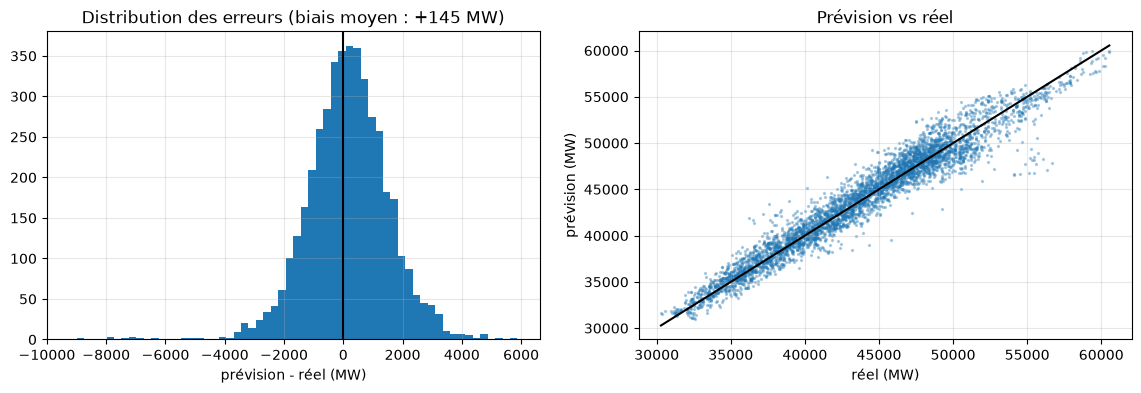

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.hist(test["error"], bins=60)
ax1.axvline(0, color="black")
ax1.set(title=f"Distribution des erreurs (biais moyen : {test['error'].mean():+.0f} MW)", xlabel="prévision - réel (MW)")
ax2.scatter(test["consommation_mw"], test["prediction"], s=2, alpha=0.3)
limits = [test["consommation_mw"].min(), test["consommation_mw"].max()]
ax2.plot(limits, limits, color="black")
ax2.set(title="Prévision vs réel", xlabel="réel (MW)", ylabel="prévision (MW)");

## Erreur selon l'heure et le jour

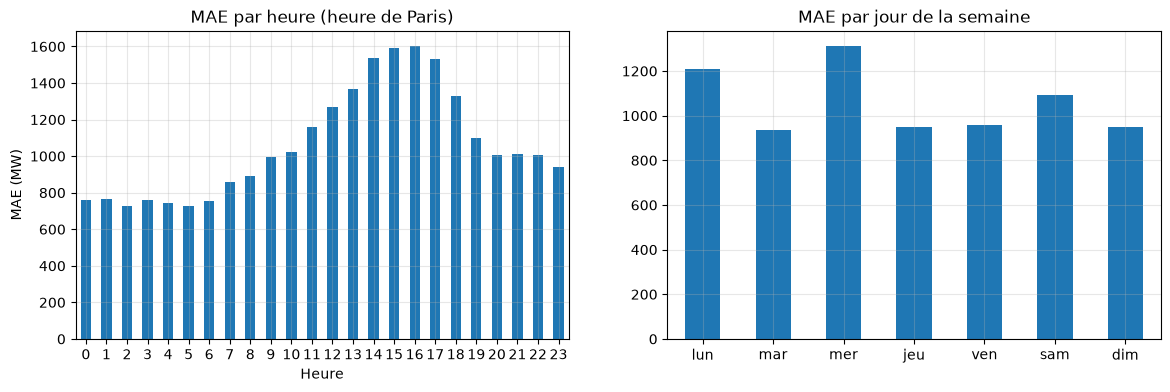

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
test.groupby(test["local"].dt.hour)["error"].apply(lambda e: e.abs().mean()).plot.bar(ax=ax1, rot=0, title="MAE par heure (heure de Paris)")
ax1.set(xlabel="Heure", ylabel="MAE (MW)")
test.groupby(test["local"].dt.dayofweek)["error"].apply(lambda e: e.abs().mean()).plot.bar(ax=ax2, rot=0, title="MAE par jour de la semaine")
ax2.set(xlabel="", xticks=range(7), xticklabels=["lun", "mar", "mer", "jeu", "ven", "sam", "dim"]);

## Les pires journées

In [4]:
daily = test.groupby(test["local"].dt.date).agg(mae=("error", lambda e: e.abs().mean()), biais=("error", "mean"))
worst = daily.sort_values("mae", ascending=False).head(8)
worst

,mae,biais
local,,
2026-07-15,4742.461911,-4742.461911
2026-08-22,2638.775301,2638.775301
2026-07-20,2146.499710,2146.499710
2026-07-01,2145.036713,2145.036713
2026-08-21,2130.399402,2130.399402
2026-07-29,2095.217471,-2095.217471
2026-06-29,1875.281920,1875.281920
2026-07-22,1817.747377,1817.747377


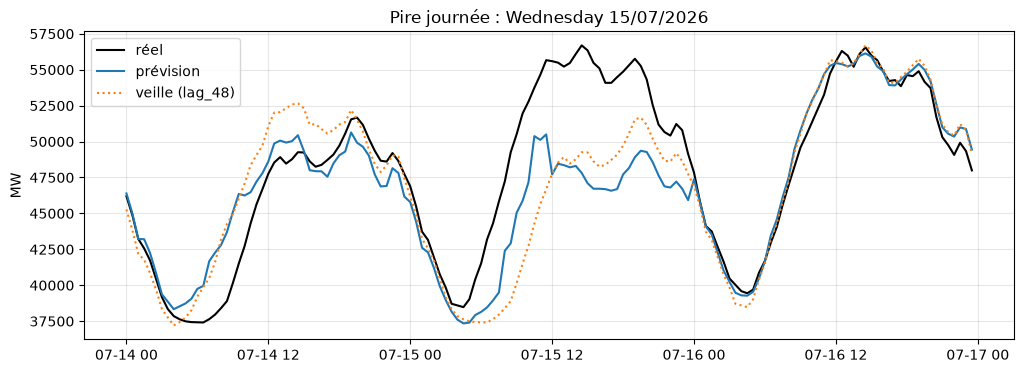

In [5]:
day = worst.index[0]
one_day = test[test["local"].dt.date.between(day - pd.Timedelta(days=1), day + pd.Timedelta(days=1))]
fig, ax = plt.subplots()
ax.plot(one_day["local"], one_day["consommation_mw"], color="black", label="réel")
ax.plot(one_day["local"], one_day["prediction"], label="prévision")
ax.plot(one_day["local"], one_day["lag_48"], linestyle=":", label="veille (lag_48)")
ax.set(title=f"Pire journée : {day:%A %d/%m/%Y}", ylabel="MW")
ax.legend();

**Lecture :** les plus grosses erreurs tombent sur les **jours fériés et leurs lendemains**. Exemple ici : le 15 juillet, la veille (14 juillet, férié) avait une consommation basse ; via `lag_48`, le modèle prévoit trop bas un jour ouvré normal. À l'inverse, un jour férié est surestimé car la veille était ouvrée. Viennent ensuite les **changements brusques de météo**.

Pistes d'amélioration, dans l'ordre du gain attendu :

1. variable **jour férié / pont** (bibliothèque `holidays`) : simple et sans risque de fuite ;
2. **température prévue** pour le lendemain (Open-Meteo) : en production il faut utiliser la *prévision* météo, pas la température observée, sinon on triche ;
3. moyennes glissantes des lags (tendance de la semaine).